# Query rewriting

In [2]:
from dotenv import load_dotenv
load_dotenv("../../.env")


from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from qdrant_client.http.models import MatchValue, FieldCondition, Filter
import openai
from qdrant_client import QdrantClient
from langsmith import traceable, get_current_run_tree
import instructor
from pydantic import BaseModel, Field

/Users/dom/Documents/GitHub/e2e-engineering-course/E2E-AI-Engineering-Bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qdrant_client = QdrantClient(url="localhost:6333")

In [4]:
class RAGContextUsed(BaseModel):
    id: str =Field(description="The ID of the item used to answer the questions")

class RAGResponse(BaseModel):
    answer: str = Field(description="Answer to the question asked")
    citations: list[RAGContextUsed] = Field(description="Relevant list of items used to answer the question")


In [5]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

In [6]:
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01",
        query=query_embedding,
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [7]:
def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

In [9]:
def rag_pipeline(question, qdrant_client, top_k=5):

    retrieved_context = retrieve_data(question, qdrant_client, k=top_k)
    preprocessed_context = process_context(retrieved_context)
    prompt = build_prompt(preprocessed_context, question)
    answer = generate_answer(prompt)

    final_answer = {
        "answer": answer.answer,
        "question": question,
        "retrieved_context_ids": retrieved_context["retrieved_context_ids"],
        "retrieved_context": retrieved_context["retrieved_context"],
        "citations": answer.citations,
    }

    return final_answer

def rag_pipeline_wrapper(question, top_k=10):
    qdrant_client = QdrantClient(url="http://qdrant:6333")

    result = rag_pipeline(question, qdrant_client, top_k=top_k)
    
    used_context = []
    for citation in result.get("citations", []):
        # extract the information for the cited items
        points = qdrant_client.scroll(
            collection_name="Amazon-items-collection-01",
            with_payload=True,
            with_vectors=False,
            scroll_filter=Filter(
                must=[
                    FieldCondition(
                        key="parent_asin",
                        match=MatchValue(
                            value=citation.id
                        )
                    )
                ]
            ),
            limit=1
        )
        
        if points and points[0]:
            payload = points[0][0].payload
            description = payload.get("preprocessed_description")
            
            if description:
                img_url = payload.get("image") or None
                product_url = f"https://www.amazon.com/dp/{citation.id}"
                
                rating = payload.get("average_rating")
                if rating is not None:
                    rating = float(rating)
                
                rating_number = payload.get("rating_number")
                if rating_number is not None:
                    rating_number = int(rating_number)

                used_context.append(
                    {
                        "description": description,
                        "img_url": img_url,
                        "product_url": product_url,
                        "rating": rating,
                        "rating_number": rating_number
                    }
                )
            
    return {
        "answer": result["answer"],
        "used_context": used_context
    }


In [10]:
def build_prompt(preprocessed_context, question):

    prompt = f"""
You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- Answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- Do not use markdown formatting.

Context:
{preprocessed_context}

Question:
{question}    
"""

    return prompt

In [ ]:
def generate_answer(prompt):
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS #use responses rather than completions API
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=RAGResponse
    )

    return response

In [12]:
query = "Can I get a tablet?"
answer = retrieve_data(query, qdrant_client, k=10)

In [13]:
answer

{'retrieved_context_ids': ['B0BG6TMXDD',
  'B09PTX6461',
  'B0C9ZWCZ99',
  'B0BXC72RLD',
  'B0BYRWPV86',
  'B09YHG2Z7F',
  'B0BM9THPDQ',
  'B0C9QZS95R',
  'B09QGRRY7G',
  'B09WCT9S1R'],
 'retrieved_context': ['Fire HD 8 & HD 8 Plus Tablet Case for Kids (Only 12th Gen, 2022 Release) - DJ&RPPQ Lightweight Shockproof Cover with Handle Stand for Kindle Fire HD 8 Kids Tablet & Kids Pro Tablet - Blue Designed for Amazon All-New Kindle Fire HD 8 & Fire HD 8 Plus Tablet, Fire HD 8 Kids tablet & Fire HD 8 Kids Pro tablet (12th Generation 2022 Release), NOT fit for other models. Cutouts for clear access to all Amazon Kindle Fire HD 8 Plus / Fire HD 8 Tablet(12TH Generation, 2022Release) / Fire HD 8 Kids Pro 2022Tablet buttons, ports, speakers and rear-camera. Raised screen bezel edges for extra protection when fall. Kindle fire 8 case made with dense heavy duty EVA foam, Material can withstand considerable wear and tear and provide extreme shock protection.Super light weight and durable hazard f

### Multi-intent Questions

In [14]:
query = "Can I get a tablet for my kid, a watch for me and a new smartphone for my girlfriend?"
answer = retrieve_data(query, qdrant_client, k=10)

In [15]:
answer

{'retrieved_context_ids': ['B09P4QW5Y2',
  'B0BG6TMXDD',
  'B09V2Y1TQB',
  'B0BMFYWK6T',
  'B0BBF2VC6X',
  'B09QGRRY7G',
  'B09KQP2H7N',
  'B0BM657X74',
  'B0BM9THPDQ',
  'B0B5CYWHWV'],
 'retrieved_context': ["Smart Watches for Women Men(Call Receive/Dial),Fitness Tracker Waterproof Smartwatch for Android iOS Phone with Text and Call Bluetooth Sport Watch Heart Rate Blood Pressure Sleep Monitor Pedometer ⌚【Elegant Fashionable Call Watch】Smart watches for women men can answer/dial calls,Equipped with 1.69-inch full touch color screen,The touch response is flexible and smooth,picture quality is high-definition.Smart watch for android phones connection app can switch more than 100 watch face UI or customize watch face.Gold steel strap watch is equipped with a black silicone strap.Equipped with 200mAh battery, fully charged for 2 hours, working time 3-5 days (Note: it depends on personal usage). 📞【Answering Calls/Dialing & Information Reminders】Mens womens smart watches uses BLE5.0 version

In [16]:
from typing import List
class QueryExpansionReponse(BaseModel):
    statements: List[str]

In [ ]:
from jinja2 import Template

def query_expansion_node(query) -> dict:
    instruction = """
    # Role: 
    - You are a query expansion module in a shopping assistent 

    # Task: 
    - You rewrite the customer query into distinct and unique statements. 
    - Generate 1 or more concise statements in natural language. 
    - Each statement describes a unique product or feature specified in the original query. 
    
    # Examples:
    
    <example>
    Query: "Can I get a smartwatch and some speakers for my house?"
    Statements: 
    - "Smartwatch"
    - "Loud Speakers"
    </example>

    <example>
    Query: "I need a warm jacket for hiking"
    Statements:
    - "insolated winter jacket"
    - "warm outdoor hiking cloths"
    </example>
    
    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        query=query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpansionReponse
    )

    return {
        "queries": response.statements
    }

In [18]:
answer = query_expansion_node(query)

In [19]:
answer

{'queries': ['Kids tablet',
  'Personal smartwatch',
  'New smartphone for girlfriend']}

## Langgraph for stitching the workflow together

### 1) Sequential query expansion

In [21]:
from operator import add
from typing import List, Annotated

class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

In [39]:
from jinja2 import Template

@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:
    instruction = """
    # Role: 
    - You are a query expansion module in a shopping assistent 

    # Task: 
    - You rewrite the customer query into distinct and unique statements. 
    - Generate 1 or more concise statements in natural language. 
    - Each statement describes a unique product or feature specified in the original query. 
    
    # Examples:
    
    <example>
    Query: "Can I get a smartwatch and some speakers for my house?"
    Statements: 
    - "Smartwatch"
    - "Loud Speakers"
    </example>

    <example>
    Query: "I need a warm jacket for hiking"
    Statements:
    - "insolated winter jacket"
    - "warm outdoor hiking cloths"
    </example>
    
    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpansionReponse
    )

    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [41]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01",
        query=query_embedding,
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])


    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context


@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:
    qdrant_client = QdrantClient(url="http://localhost:6333")

    retireved_context = []

    for query in state.expanded_query:
        retireved_context.append(retrieve_data(query, qdrant_client, k=7))

    return {
        "retrieved_context": retireved_context
    }

### Aggregator Node

In [49]:
class AggregatorResponse(BaseModel):
    answer: str

@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retrieved_context)

    instruction = """
    # Role: 
    - You are a shopping assistent that can answer questions to the available products.

    # Task: 
    - You will be given a query and a list of context that should be used to answer the query
    - Do not invent or hallucinate items in stock
    - Don't use the word context instead refer to them as the items in stock
    - The answer should contain detailed information grounded in the given product specifications
    - If there are no relevant informations in the context assume that there is no product matching the users query
    
    # Context:
    <context>
    {{ context }}
    </context>

    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        context=preprocessed_context,
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

### RAG Graph

In [50]:
from langgraph.prebuilt import ToolNode

workflow = StateGraph(State)


# nodes
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

# edges
workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()


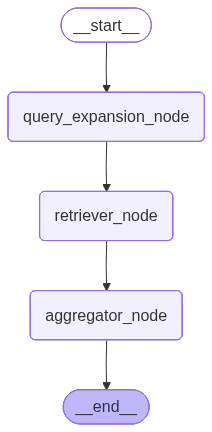

In [51]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

In [52]:
query = "Can I get a tablet for my kid, a watch for me and a new smartphone for my girlfriend?"

initial_state = {
    "initial_query": query
}

In [53]:
result = graph.invoke(initial_state)

In [54]:
result

{'expanded_query': ['Tablet for a child',
  'Smartwatch for the user',
  'New smartphone for a girlfriend'],
 'retrieved_context': ['- ID: B0BG6TMXDD, rating: 4.4, description: Fire HD 8 & HD 8 Plus Tablet Case for Kids (Only 12th Gen, 2022 Release) - DJ&RPPQ Lightweight Shockproof Cover with Handle Stand for Kindle Fire HD 8 Kids Tablet & Kids Pro Tablet - Blue Designed for Amazon All-New Kindle Fire HD 8 & Fire HD 8 Plus Tablet, Fire HD 8 Kids tablet & Fire HD 8 Kids Pro tablet (12th Generation 2022 Release), NOT fit for other models. Cutouts for clear access to all Amazon Kindle Fire HD 8 Plus / Fire HD 8 Tablet(12TH Generation, 2022Release) / Fire HD 8 Kids Pro 2022Tablet buttons, ports, speakers and rear-camera. Raised screen bezel edges for extra protection when fall. Kindle fire 8 case made with dense heavy duty EVA foam, Material can withstand considerable wear and tear and provide extreme shock protection.Super light weight and durable hazard free safe material perfect for kid

In [55]:
result["answer"]

'Yes—based on the items available, I can help with a kid’s tablet case, a smartwatch, and a phone, but I only see matching products for the tablet (case), smartwatch, and not a smartphone in the available list.'

### 2) Parallel Query Expansion

In [64]:
from operator import add
from typing import List, Annotated

class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

In [65]:
from jinja2 import Template

@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:
    instruction = """
    # Role: 
    - You are a query expansion module in a shopping assistent 

    # Task: 
    - You rewrite the customer query into distinct and unique statements. 
    - Generate 1 or more concise statements in natural language. 
    - Each statement describes a unique product or feature specified in the original query. 
    
    # Examples:
    
    <example>
    Query: "Can I get a smartwatch and some speakers for my house?"
    Statements: 
    - "Smartwatch"
    - "Loud Speakers"
    </example>

    <example>
    Query: "I need a warm jacket for hiking"
    Statements:
    - "insolated winter jacket"
    - "warm outdoor hiking cloths"
    </example>
    
    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpansionReponse
    )

    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [66]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State):

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01",
        query=query_embedding,
        limit=state["k"]
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])


    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Aggregator Node

In [67]:
class AggregatorResponse(BaseModel):
    answer: str

@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retrieved_context)

    instruction = """
    # Role: 
    - You are a shopping assistent that can answer questions to the available products.

    # Task: 
    - You will be given a query and a list of context that should be used to answer the query
    - Do not invent or hallucinate items in stock
    - Don't use the word context instead refer to them as the items in stock
    - The answer should contain detailed information grounded in the given product specifications
    - If there are no relevant informations in the context assume that there is no product matching the users query
    
    # Context:
    <context>
    {{ context }}
    </context>

    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        context=preprocessed_context,
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [68]:
from langgraph.types import Send

def query_expand_conditional_edges(state: State) -> dict:
    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

In [69]:
workflow = StateGraph(State)

# nodes
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

# edges
workflow.add_edge(START, "query_expansion_node")
workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()


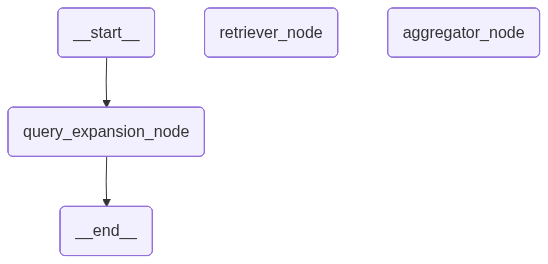

In [ ]:
# We dont know how many retreiver_nodes will be expanded all of those will be connecting to the aggregator_node, but we cannot display it
display(Image(
    graph.get_graph().draw_mermaid_png()
))

In [71]:
initial_state = {
    "initial_query": query
}

result = graph.invoke(initial_state)

In [72]:
result

{'expanded_query': ['Kids tablet',
  'Smartwatch for me',
  'New smartphone for my girlfriend'],
 'retrieved_context': ['- ID: B0BG6TMXDD, rating: 4.4, description: Fire HD 8 & HD 8 Plus Tablet Case for Kids (Only 12th Gen, 2022 Release) - DJ&RPPQ Lightweight Shockproof Cover with Handle Stand for Kindle Fire HD 8 Kids Tablet & Kids Pro Tablet - Blue Designed for Amazon All-New Kindle Fire HD 8 & Fire HD 8 Plus Tablet, Fire HD 8 Kids tablet & Fire HD 8 Kids Pro tablet (12th Generation 2022 Release), NOT fit for other models. Cutouts for clear access to all Amazon Kindle Fire HD 8 Plus / Fire HD 8 Tablet(12TH Generation, 2022Release) / Fire HD 8 Kids Pro 2022Tablet buttons, ports, speakers and rear-camera. Raised screen bezel edges for extra protection when fall. Kindle fire 8 case made with dense heavy duty EVA foam, Material can withstand considerable wear and tear and provide extreme shock protection.Super light weight and durable hazard free safe material perfect for kids and grownu

In [74]:
print(result["answer"])

I can help with tablet and watch options from the items in stock. I don’t have any smartphone in stock from the listed items—so I can’t recommend one for your girlfriend.


Result: In total the parallel execution saved about 0,3 seconds of latency compared to the sequential retrieval.